In [ ]:
import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import hdbscan
from hdbscan.validity import validity_index
from mlxtend.frequent_patterns import apriori, association_rules

# Set pandas display options
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

### loads `.env`
#### Setting up the `database connection`

In [3]:
load_dotenv()

pg_url = (
    f"postgresql+psycopg2://{os.getenv('PGUSER')}:{os.getenv('PGPASSWORD')}"
    f"@{os.getenv('PGHOST')}:{os.getenv('PGPORT')}/{os.getenv('PGDATABASE')}"
)

engine = create_engine(pg_url, pool_pre_ping=True)

with engine.begin() as conn:
    conn.execute(text("SET search_path TO mart, curated, public;"))

with engine.begin() as conn:
    print(conn.execute(text("SELECT now()")).scalar())

2025-12-04 09:46:28.627900-05:00


`38% (~212796)` fraudulent claims detected out of `558211` total claims
- `IP - 23402` (~11%) fraudulent records<br>
- `OP - 189394` (~89%) fraudulent records

#### 4 -  `HDBSCAN clustering` of fraudulent claims (IP & OP)

#### 4.1 Validate HDBSCAN clusters (DBCV + ARI)

In [ ]:
# HDBSCAN re-tune for lower noise & better DBCV (IP & OP)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Load fraud-only claims
ip_raw = pd.read_sql("SELECT * FROM mart.fraud_claims_ip", con=engine)
op_raw = pd.read_sql("SELECT * FROM mart.fraud_claims_op", con=engine)

# Strong preprocessing
def build_matrix_strong(df, claim_type):
    if claim_type == "IP":
        feats = ["reimb_amt", "deductible_paid", "dx_count", "px_count", "los_days",
                 "z_ip_reimb", "z_ip_los", "dup_exact_flag", "dup_near_count",
                 "overcharge_z_flag", "overcharge_iqr_flag"]
    else:
        feats = ["reimb_amt", "deductible_paid", "dx_count", "px_count",
                 "z_op_reimb", "dup_exact_flag", "dup_near_count",
                 "overcharge_z_flag", "overcharge_iqr_flag"]

    X = df[feats].apply(pd.to_numeric, errors="coerce").copy()
    # engineer robust $ features
    X["reimb_amt_log"] = np.log1p(X["reimb_amt"].clip(lower=0))
    denom = df["reimb_amt"].replace(0, np.nan)
    X["deductible_share"] = (df["deductible_paid"] / denom).clip(0, 5)

    # drop raw $ after deriving
    X = X.drop(
        columns=[c for c in ["reimb_amt", "deductible_paid"] if c in X.columns])

    # drop constant cols (zero variance -> zero distances)
    nunq = X.nunique(dropna=True)
    keep_cols = nunq[nunq > 1].index.tolist()
    X = X[keep_cols]

    # fill NA with medians; robust scale
    X = X.fillna(X.median(numeric_only=True))
    Xs = RobustScaler().fit_transform(X)

    # drop duplicate rows in scaled space (avoid exact zero distances)
    Xs_df = pd.DataFrame(Xs, columns=keep_cols, index=df.index)
    Xs_df = Xs_df[~Xs_df.duplicated(keep="first")]
    df_clean = df.loc[Xs_df.index].copy()

    # tiny jitter to be extra-safe for DBCV numerical ops
    rng = np.random.RandomState(42)
    Xs_jitter = Xs_df.values + 1e-9 * rng.normal(size=Xs_df.shape)

    return df_clean, Xs_jitter, keep_cols

ip_df, Xs_ip, cols_ip = build_matrix_strong(ip_raw, "IP")
op_df, Xs_op, cols_op = build_matrix_strong(op_raw, "OP")

# Auto-tune HDBSCAN
def pct(n, p):
    return max(10, int(np.ceil(n * p)))

def tune_hdbscan(Xs, min_cluster_size_grid, min_samples_grid,
                 methods=("leaf", "eom"), metrics=("euclidean", "manhattan")):
    best = {"dbcv": -np.inf}
    n = Xs.shape[0]
    for mcs in min_cluster_size_grid:
        for ms in min_samples_grid:
            for method in methods:
                for metric in metrics:
                    clus = hdbscan.HDBSCAN(min_cluster_size=mcs,
                                           min_samples=ms,
                                           cluster_selection_method=method,
                                           metric=metric,
                                           prediction_data=True)
                    labels = clus.fit_predict(Xs)
                    k = len(set(labels)) - (1 if -1 in labels else 0)
                    noise = float((labels == -1).mean())
                    if k >= 2:
                        try:
                            dbcv = float(validity_index(Xs, labels))
                        except Exception:
                            dbcv = -np.inf
                    else:
                        dbcv = -np.inf
                    score_tuple = (dbcv, -noise, k)
                    if score_tuple > (best["dbcv"], -best.get("noise", 1.0), best.get("k", 0)):
                        best.update({
                            "dbcv": dbcv, "noise": noise, "k": int(k),
                            "min_cluster_size": mcs, "min_samples": ms,
                            "method": method, "metric": metric,
                            "labels": labels, "model": clus
                        })
    return best

grid_ip = {"mcs": [pct(Xs_ip.shape[0], p) for p in (0.01, 0.015, 0.02)],
           "ms":  [5, 7, 10]}
grid_op = {"mcs": [pct(Xs_op.shape[0], p) for p in (0.01, 0.015, 0.02)],
           "ms":  [5, 7, 10]}

best_ip = tune_hdbscan(Xs_ip, grid_ip["mcs"], grid_ip["ms"])
best_op = tune_hdbscan(Xs_op, grid_op["mcs"], grid_op["ms"])

print("Best IP params:",
      {k: best_ip[k] for k in ["dbcv", "noise", "k", "min_cluster_size", "min_samples", "method", "metric"]})
print("Best OP params:",
      {k: best_op[k] for k in ["dbcv", "noise", "k", "min_cluster_size", "min_samples", "method", "metric"]})

# attach labels to cleaned frames
ip = ip_df.copy()
ip["cluster"] = best_ip["labels"]
op = op_df.copy()
op["cluster"] = best_op["labels"]

# Persist results to DB
ip_out_table = "fraud_claims_ip_clusters"
op_out_table = "fraud_claims_op_clusters"

# keep original columns + cluster
ip.to_sql(ip_out_table, con=engine, schema="mart",
          index=False, if_exists="replace")
op.to_sql(op_out_table, con=engine, schema="mart",
          index=False, if_exists="replace")

runlog = pd.DataFrame([{
    "run_ts": datetime.utcnow().isoformat(),
    "table_in_ip": "mart.fraud_claims_ip",
    "table_in_op": "mart.fraud_claims_op",
    "table_out_ip": f"mart.{ip_out_table}",
    "table_out_op": f"mart.{op_out_table}",
    "ip_dbcv": best_ip["dbcv"], "ip_noise": best_ip["noise"], "ip_k": best_ip["k"],
    "ip_min_cluster_size": best_ip["min_cluster_size"], "ip_min_samples": best_ip["min_samples"],
    "ip_method": best_ip["method"], "ip_metric": best_ip["metric"],
    "op_dbcv": best_op["dbcv"], "op_noise": best_op["noise"], "op_k": best_op["k"],
    "op_min_cluster_size": best_op["min_cluster_size"], "op_min_samples": best_op["min_samples"],
    "op_method": best_op["method"], "op_metric": best_op["metric"]
}])

print("\nWrote:")
print(f"  mart.{ip_out_table}  (rows={len(ip)})")
print(f"  mart.{op_out_table}  (rows={len(op)})")
print("  mart.hdbscan_runs    (+1 row)")

c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\zayed\anaconda3\envs\KNCVU\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 

Best IP params: {'dbcv': 0.1296742408195641, 'noise': 0.31559187279151946, 'k': 19, 'min_cluster_size': 340, 'min_samples': 10, 'method': 'leaf', 'metric': 'manhattan'}
Best OP params: {'dbcv': 0.18808329243753363, 'noise': 0.155209324452902, 'k': 11, 'min_cluster_size': 127, 'min_samples': 7, 'method': 'eom', 'metric': 'manhattan'}


InternalError: (psycopg2.errors.DependentObjectsStillExist) cannot drop table fraud_claims_ip_clusters because other objects depend on it
DETAIL:  view cluster_signature_hits_fraudonly_enriched depends on table fraud_claims_ip_clusters
view claim_signature_alerts_fraudonly depends on view cluster_signature_hits_fraudonly_enriched
HINT:  Use DROP ... CASCADE to drop the dependent objects too.

[SQL: 
DROP TABLE mart.fraud_claims_ip_clusters]
(Background on this error at: https://sqlalche.me/e/20/2j85)

#### 4.2 — Cluster cards (fraudulent IP & OP claims)

Saved cluster cards -> fraud_ip_cluster_cards.csv, fraud_op_cluster_cards.csv


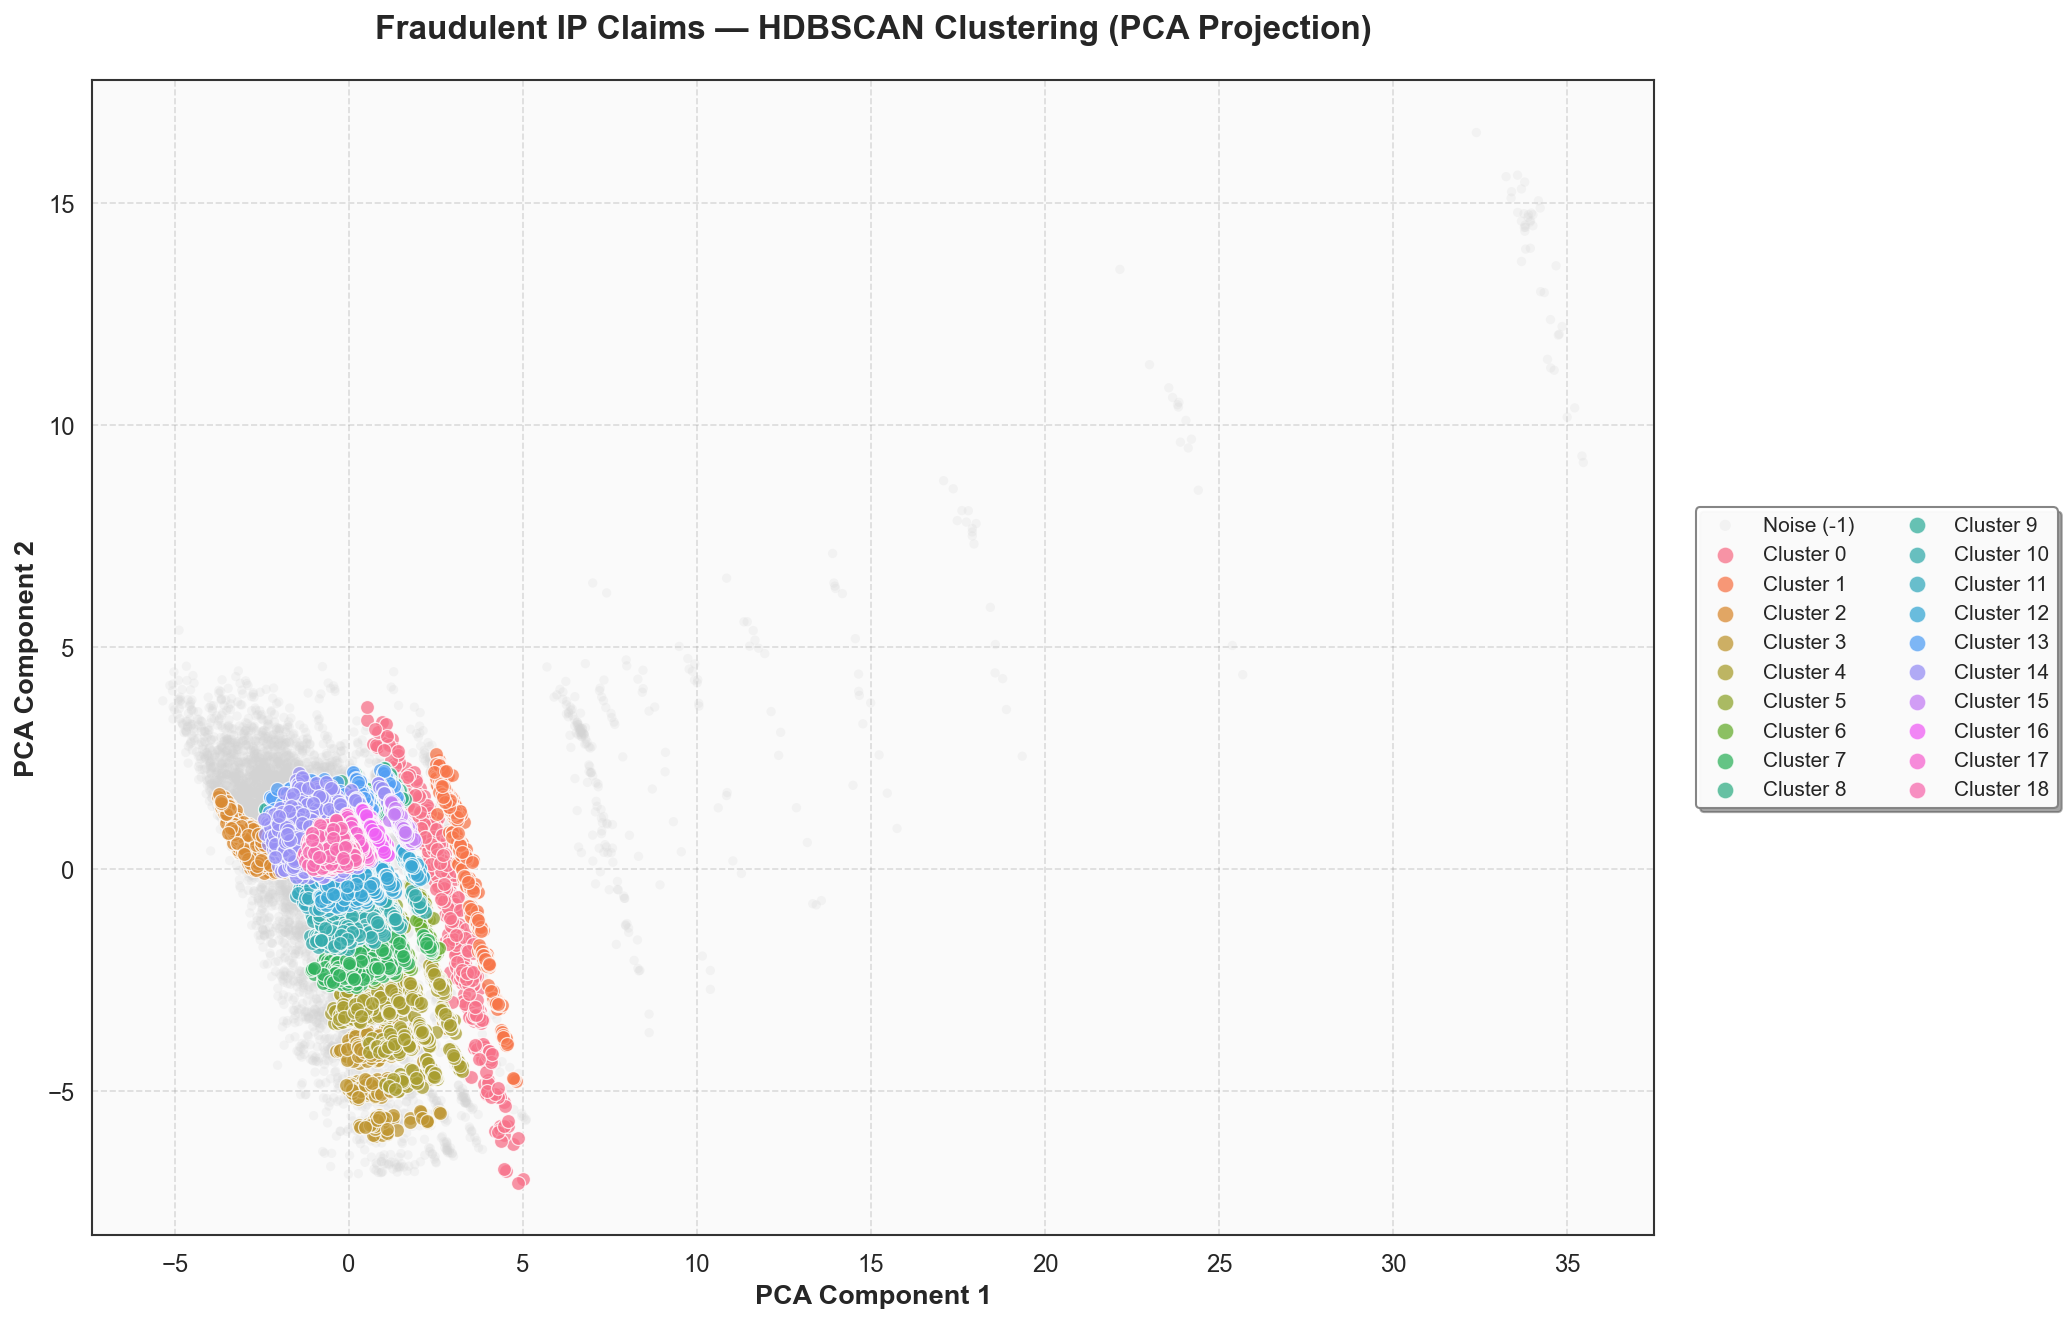

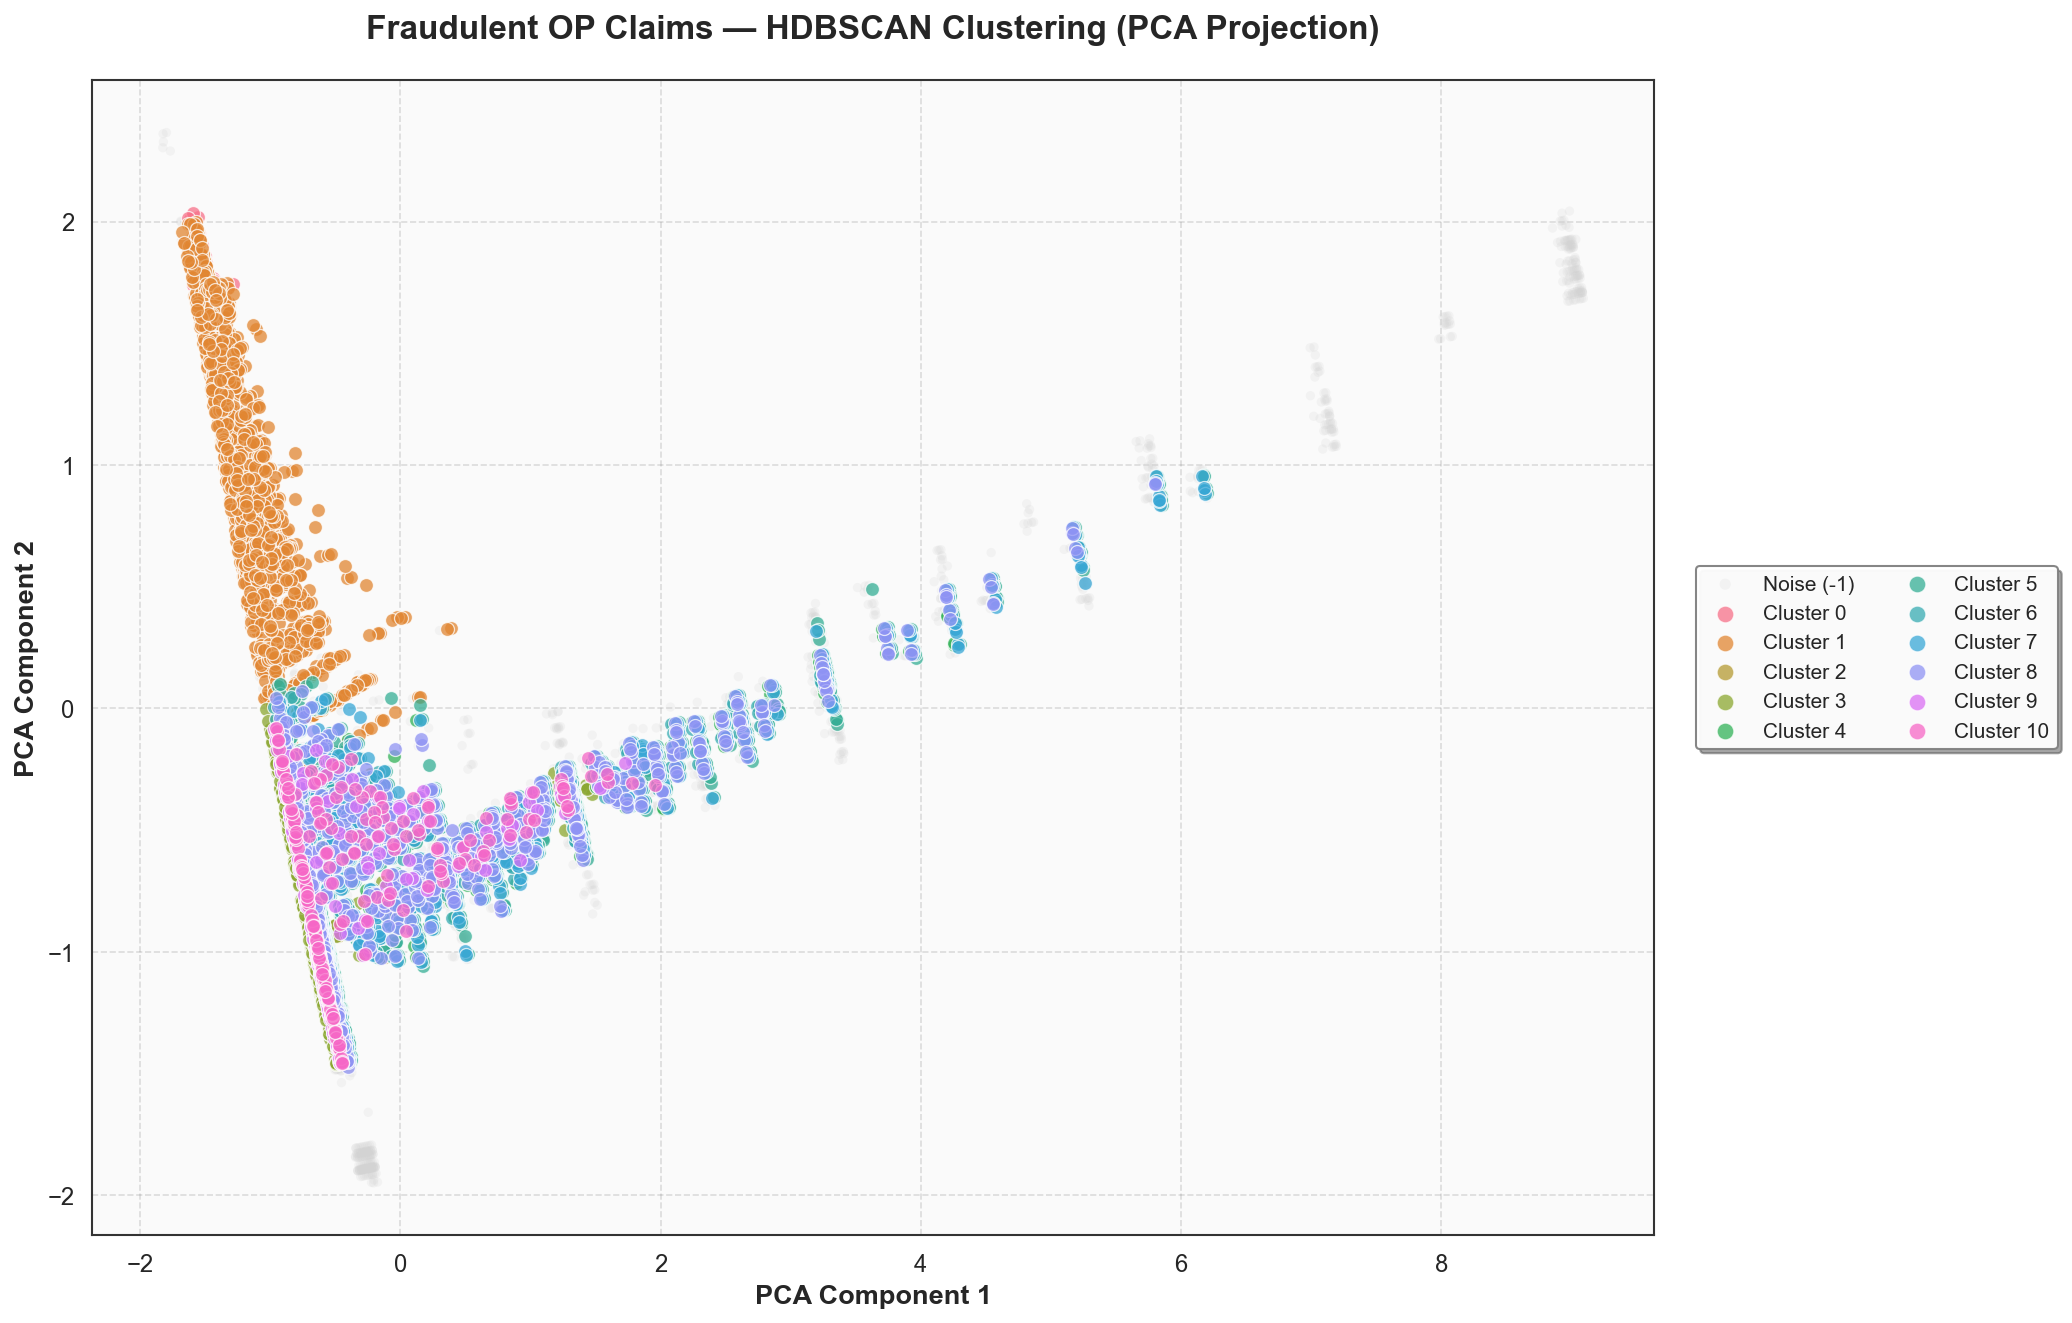

IP PCA variance explained (2D): 0.625
OP PCA variance explained (2D): 0.874


In [ ]:
# ===== Step 4.2 — Cluster Cards + PCA Scatter Maps (IP & OP) =====

# -------------------------------------------------------------------
# 1) Load the clustered fraud-only claims written by your tuning step
# -------------------------------------------------------------------
ip = pd.read_sql("SELECT * FROM mart.fraud_claims_ip_clusters", con=engine)
op = pd.read_sql("SELECT * FROM mart.fraud_claims_op_clusters", con=engine)

# -------------------------------------------------------------------
# 2) Cluster cards (exclude noise = -1)
#    - n, total_paid, median_paid
#    - robust medians of interpretable features per cluster
# -------------------------------------------------------------------


def _present(cols, df):
    return [c for c in cols if c in df.columns]


def make_cluster_cards(df, claim_type):
    core = df[df["cluster"] != -1].copy()
    if core.empty:
        return pd.DataFrame()

    money = core.groupby("cluster")["reimb_amt"].agg(
        n="count", total_paid="sum", median_paid="median"
    )

    base_feats = ["dx_count", "px_count", "dup_exact_flag", "dup_near_count",
                  "overcharge_z_flag", "overcharge_iqr_flag"]
    if claim_type == "IP":
        base_feats += ["los_days", "z_ip_reimb", "z_ip_los"]
    else:
        base_feats += ["z_op_reimb"]

    feat_cols = _present(base_feats, core)
    stats = core.groupby("cluster")[feat_cols].median(numeric_only=True)
    cards = (money.join(stats)
                  .reset_index()
                  .sort_values(["n", "total_paid"], ascending=[False, False]))
    return cards


ip_cards = make_cluster_cards(ip, "IP")
op_cards = make_cluster_cards(op, "OP")

ip_cards.to_csv("fraud_ip_cluster_cards.csv", index=False)
op_cards.to_csv("fraud_op_cluster_cards.csv", index=False)
print("Saved cluster cards -> fraud_ip_cluster_cards.csv, fraud_op_cluster_cards.csv")

# -------------------------------------------------------------------
# 3) PCA scatter maps (noise in light gray, clusters colored)
#    PCA is a linear projection to 2D for VISUALIZATION ONLY.
#    Features are RobustScaled (median/IQR) to handle heavy tails.
# -------------------------------------------------------------------


def build_matrix_for_pca(df, claim_type):
    # match the tuning features (with $ transforms)
    if claim_type == "IP":
        feats = ["reimb_amt", "deductible_paid", "dx_count", "px_count", "los_days",
                 "z_ip_reimb", "z_ip_los", "dup_exact_flag", "dup_near_count",
                 "overcharge_z_flag", "overcharge_iqr_flag"]
    else:
        feats = ["reimb_amt", "deductible_paid", "dx_count", "px_count",
                 "z_op_reimb", "dup_exact_flag", "dup_near_count",
                 "overcharge_z_flag", "overcharge_iqr_flag"]

    X = df[_present(feats, df)].apply(pd.to_numeric, errors="coerce").copy()

    # Derive log$ & deductible share, then drop raw $ columns
    if "reimb_amt" in X.columns:
        X["reimb_amt_log"] = np.log1p(X["reimb_amt"].clip(lower=0))
    if "deductible_paid" in X.columns and "reimb_amt" in df.columns:
        denom = df["reimb_amt"].replace(0, np.nan)
        X["deductible_share"] = (df["deductible_paid"] / denom).clip(0, 5)

    X = X.drop(
        columns=[c for c in ["reimb_amt", "deductible_paid"] if c in X.columns])

    # Drop constant columns, fill NA with medians, Robust scale
    nunq = X.nunique(dropna=True)
    keep = nunq[nunq > 1].index.tolist()
    if not keep:
        raise ValueError(
            "All features constant/empty after filtering; cannot plot PCA.")
    X = X[keep].fillna(X.median(numeric_only=True))

    # centers by median, scales by IQR
    Xs = RobustScaler().fit_transform(X)
    return Xs


def pca_2d(Xs):
    # linear projection to 2D
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(Xs)
    return Z, pca.explained_variance_ratio_.sum()


def plot_pca_scatter(Z, labels, title, fname):
    """Professional-quality PCA scatter plot with seaborn styling"""
    labels = np.asarray(labels)
    uniq = np.unique(labels)
    
    # Create DataFrame for easier manipulation
    plot_df = pd.DataFrame({
        'PCA1': Z[:, 0],
        'PCA2': Z[:, 1],
        'Cluster': labels.astype(str)
    })
    
    # Separate noise from clusters
    noise_df = plot_df[plot_df['Cluster'] == '-1']
    cluster_df = plot_df[plot_df['Cluster'] != '-1']
    
    # Set publication-quality seaborn style
    sns.set_context("paper", font_scale=1.3)
    sns.set_style("whitegrid", {
        'grid.linestyle': '--',
        'grid.alpha': 0.3,
        'axes.edgecolor': '.2',
        'axes.linewidth': 1.2
    })
    
    # Create figure with high DPI for crisp output
    fig, ax = plt.subplots(figsize=(14, 9), dpi=150)
    
    # Plot noise points first (subtle gray background)
    if len(noise_df) > 0:
        ax.scatter(noise_df['PCA1'], noise_df['PCA2'], 
                  s=20, alpha=0.2, color='#d3d3d3', 
                  label='Noise (-1)', edgecolors='none', rasterized=True)
    
    # Plot clusters with vibrant seaborn palette
    if len(cluster_df) > 0:
        unique_clusters = sorted(cluster_df['Cluster'].unique(), key=lambda x: int(x))
        n_clusters = len(unique_clusters)
        
        # Use professional color palette
        if n_clusters <= 10:
            palette = sns.color_palette("tab10", n_clusters)
        else:
            palette = sns.color_palette("husl", n_clusters)
        
        for i, cluster in enumerate(unique_clusters):
            cluster_points = cluster_df[cluster_df['Cluster'] == cluster]
            ax.scatter(cluster_points['PCA1'], cluster_points['PCA2'],
                      s=45, alpha=0.75, color=palette[i],
                      label=f'Cluster {cluster}', 
                      edgecolors='white', linewidth=0.6)
    
    # Professional styling
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20, family='sans-serif')
    ax.set_xlabel('PCA Component 1', fontsize=13, fontweight='bold', family='sans-serif')
    ax.set_ylabel('PCA Component 2', fontsize=13, fontweight='bold', family='sans-serif')
    
    # Enhanced grid
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8, color='gray')
    ax.set_facecolor('#fafafa')
    
    # Professional legend with optimal placement
    if len(cluster_df) > 0:
        ncol = 1 if n_clusters <= 8 else 2
        legend = ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                          frameon=True, shadow=True, fancybox=True,
                          fontsize=10, ncol=ncol, markerscale=1.2)
        legend.get_frame().set_facecolor('white')
        legend.get_frame().set_alpha(0.95)
        legend.get_frame().set_edgecolor('gray')
        legend.get_frame().set_linewidth(1)
    
    # Tight layout for publication quality
    plt.tight_layout()
    
    # Save with high quality
    plt.savefig(fname, bbox_inches="tight", dpi=300, facecolor='white')
    plt.show()
    
    # Reset to default style
    sns.set_style("whitegrid")


# IP
Xs_ip = build_matrix_for_pca(ip, "IP")
Z_ip, ip_var = pca_2d(Xs_ip)
plot_pca_scatter(Z_ip, ip["cluster"].to_numpy(),
                 "Fraudulent IP Claims — HDBSCAN Clustering (PCA Projection)",
                 "fraudulent_ip_claims_pca.png")

# OP
Xs_op = build_matrix_for_pca(op, "OP")
Z_op, op_var = pca_2d(Xs_op)
plot_pca_scatter(Z_op, op["cluster"].to_numpy(),
                 "Fraudulent OP Claims — HDBSCAN Clustering (PCA Projection)",
                 "fraudulent_op_claims_pca.png")

print(f"IP PCA variance explained (2D): {ip_var:.3f}")
print(f"OP PCA variance explained (2D): {op_var:.3f}")

#### 4.3 - mine association rules (dx/px patterns) inside each HDBSCAN cluster

In [ ]:
# 1) Load clustered fraud-only claims (created in 4.1) and normalized codes
ip = pd.read_sql(
    "SELECT claimid, cluster FROM mart.fraud_claims_ip_clusters", con=engine)
op = pd.read_sql(
    "SELECT claimid, cluster FROM mart.fraud_claims_op_clusters", con=engine)
codes = pd.read_sql(
    "SELECT claimid, item FROM mart.claim_codes", con=engine).drop_duplicates()

# 2) Helper: mine rules within each cluster of a given dataframe (ip or op)
def mine_rules_by_cluster(df_claims, claim_type, min_support=0.02, min_conf=0.6, min_lift=1.2, top_items=300):
    # Join cluster labels to codes (exclude noise = -1)
    cc = df_claims[df_claims["cluster"] != -
                   1].merge(codes, on="claimid", how="inner")
    results = []

    # Loop over clusters
    for c in sorted(cc["cluster"].unique()):
        sub = cc[cc["cluster"] == c][["claimid", "item"]].drop_duplicates()

        # Optional: restrict to most common items for tractability
        popular = sub["item"].value_counts().head(top_items).index
        sub = sub[sub["item"].isin(popular)]

        # One-hot encode: transactions x items (bool)
        basket = pd.crosstab(sub["claimid"], sub["item"]).astype(bool)

        # Dynamic min_support: ensure at least ~30 claims for antecedent coverage if cluster is small
        ms = max(min_support, 30 / max(1, basket.shape[0]))

        # Apriori frequent itemsets
        itemsets = apriori(basket, min_support=ms, use_colnames=True)
        if itemsets.empty:
            continue

        # Association rules with confidence & lift
        rules = association_rules(
            itemsets, metric="confidence", min_threshold=min_conf)
        if rules.empty:
            continue

        # Filter by lift (strength above chance) and sort
        rules = rules[rules["lift"] >= min_lift].copy()
        if rules.empty:
            continue

        # Add convenience columns
        n_claims = basket.shape[0]
        rules["cluster"] = c
        rules["claim_type"] = claim_type
        rules["n_in_cluster"] = n_claims
        # Convert frozensets to readable strings
        rules["antecedents_str"] = rules["antecedents"].apply(
            lambda s: "+".join(sorted(map(str, s))))
        rules["consequents_str"] = rules["consequents"].apply(
            lambda s: "+".join(sorted(map(str, s))))
        # Coverage counts inside the cluster
        rules["antecedent_cov"] = (
            rules["support"] * n_claims).round().astype(int)

        # Keep tidy columns
        keep = ["claim_type", "cluster", "n_in_cluster", "antecedents_str", "consequents_str",
                "support", "confidence", "lift", "antecedent_cov"]
        results.append(rules[keep].sort_values(
            ["lift", "support"], ascending=False))

    if not results:
        return pd.DataFrame(columns=["claim_type", "cluster", "n_in_cluster", "antecedents_str", "consequents_str",
                                     "support", "confidence", "lift", "antecedent_cov"])
    return pd.concat(results, ignore_index=True)


# 3) Mine rules for IP and OP
ip_rules = mine_rules_by_cluster(
    ip, "IP", min_support=0.02, min_conf=0.6, min_lift=1.2, top_items=300)
op_rules = mine_rules_by_cluster(
    op, "OP", min_support=0.02, min_conf=0.6, min_lift=1.2, top_items=300)

# 4) Save per-claim_type CSVs and one combined file
ip_rules.to_csv("fraud_ip_association_rules.csv", index=False)
op_rules.to_csv("fraud_op_association_rules.csv", index=False)
both = pd.concat([ip_rules, op_rules], ignore_index=True)
both.to_csv("fraud_association_rules_all.csv", index=False)

print("Saved:",
      "fraud_ip_association_rules.csv,",
      "fraud_op_association_rules.csv,",
      "fraud_association_rules_all.csv")

# 5) Quick peek (top 10 strongest rules by lift)
display_cols = ["claim_type", "cluster", "n_in_cluster", "antecedents_str", "consequents_str",
                "support", "confidence", "lift", "antecedent_cov"]
print("\nTop rules (by lift):")
print(both.sort_values(["lift", "support"], ascending=False)[
      display_cols].head(10).to_string(index=False))

Saved: fraud_ip_association_rules.csv, fraud_op_association_rules.csv, fraud_association_rules_all.csv

Top rules (by lift):
claim_type  cluster  n_in_cluster antecedents_str consequents_str  support  confidence  lift  antecedent_cov
        OP        1          2419         280+285             588     0.04        0.77 10.13              95
        OP        1          2419         285+588             280     0.04        0.69  9.46              95
        IP       18          1573             995             038     0.03        0.64  8.90              49
        OP        1          2419             V56             588     0.02        0.64  8.43              58
        OP        1          2419             588             280     0.05        0.61  8.41             112
        OP        1          2419             280             588     0.05        0.64  8.41             112
        IP       14          4107            8154             715     0.03        0.86  7.42             126
   

#### K-Means Clustering Implementation

##### 4.K.1 – Load fraud claims + build feature matrices

In [26]:
# 1) Load fraud-only IP & OP claims
df_ip = pd.read_sql("SELECT * FROM mart.fraud_claims_ip", con=engine)
df_op = pd.read_sql("SELECT * FROM mart.fraud_claims_op", con=engine)

print("IP fraud claims shape:", df_ip.shape)
print("OP fraud claims shape:", df_op.shape)

# 2) Use the same feature sets from HDBSCAN
ip_feat_cols = [
    "reimb_amt", "deductible_paid", "dx_count", "px_count", "los_days",
    "z_ip_reimb", "z_ip_los", "dup_exact_flag", "dup_near_count",
    "overcharge_z_flag", "overcharge_iqr_flag"
]

op_feat_cols = [
    "reimb_amt", "deductible_paid", "dx_count", "px_count",
    "z_op_reimb", "dup_exact_flag", "dup_near_count",
    "overcharge_z_flag", "overcharge_iqr_flag"
]

# sanity check: all columns exist
missing_ip = [c for c in ip_feat_cols if c not in df_ip.columns]
missing_op = [c for c in op_feat_cols if c not in df_op.columns]
print("Missing IP features:", missing_ip)
print("Missing OP features:", missing_op)

IP fraud claims shape: (23402, 23)
OP fraud claims shape: (189394, 19)
Missing IP features: []
Missing OP features: []


##### 4.K.2 – Run KMeans + pick k using silhouette 

In [27]:
# Extract feature matrix for IP
X_ip = df_ip[ip_feat_cols].copy()

# Impute (median) and scale
imp_ip = SimpleImputer(strategy="median")
X_ip_imp = imp_ip.fit_transform(X_ip)

scaler_ip = StandardScaler()
X_ip_scaled = scaler_ip.fit_transform(X_ip_imp)

print("X_ip_scaled shape:", X_ip_scaled.shape)

X_ip_scaled shape: (23402, 11)


In [28]:
k_range_ip = range(2, 11)  # try k = 2..10
sil_scores_ip = []

for k in k_range_ip:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels_k = km.fit_predict(X_ip_scaled)
    sil = silhouette_score(X_ip_scaled, labels_k)
    sil_scores_ip.append(sil)
    print(f"IP: k={k}, silhouette={sil:.4f}")

best_k_ip = k_range_ip[int(np.argmax(sil_scores_ip))]
print(f"\nChosen k for IP (max silhouette): {best_k_ip}")

IP: k=2, silhouette=0.5988
IP: k=3, silhouette=0.5850
IP: k=3, silhouette=0.5850
IP: k=4, silhouette=0.3835
IP: k=4, silhouette=0.3835
IP: k=5, silhouette=0.3961
IP: k=5, silhouette=0.3961
IP: k=6, silhouette=0.3420
IP: k=6, silhouette=0.3420
IP: k=7, silhouette=0.2963
IP: k=7, silhouette=0.2963
IP: k=8, silhouette=0.2981
IP: k=8, silhouette=0.2981
IP: k=9, silhouette=0.2944
IP: k=9, silhouette=0.2944
IP: k=10, silhouette=0.2961

Chosen k for IP (max silhouette): 2
IP: k=10, silhouette=0.2961

Chosen k for IP (max silhouette): 2


In [29]:
kmeans_ip = KMeans(
    n_clusters=best_k_ip,
    random_state=42,
    n_init=20
)
ip_labels = kmeans_ip.fit_predict(X_ip_scaled)

df_ip["kmeans_cluster_ip"] = ip_labels
print(df_ip["kmeans_cluster_ip"].value_counts().sort_index())

kmeans_cluster_ip
0     2194
1    21208
Name: count, dtype: int64


IP PCA variance explained (2D): 0.5142016935255621


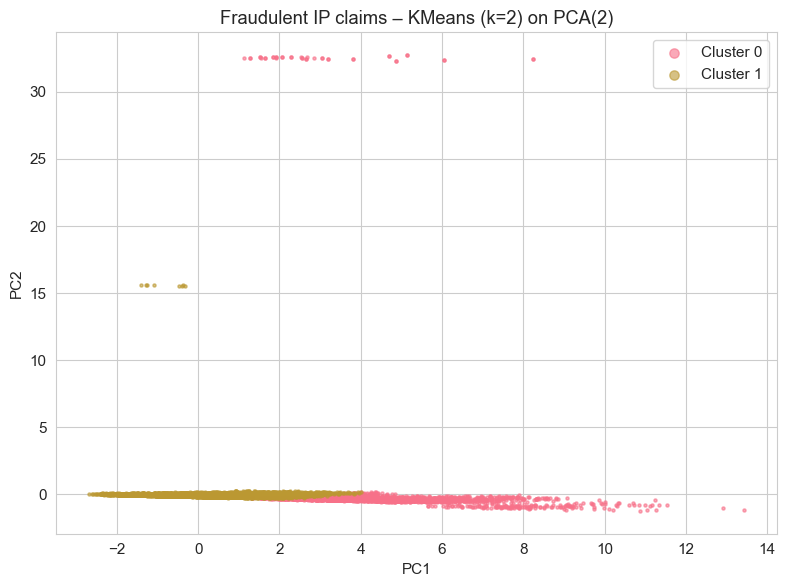

In [30]:
pca_ip = PCA(n_components=2, random_state=42)
X_ip_pca = pca_ip.fit_transform(X_ip_scaled)

df_ip["pca1_ip"] = X_ip_pca[:, 0]
df_ip["pca2_ip"] = X_ip_pca[:, 1]

print("IP PCA variance explained (2D):",
      pca_ip.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
for cl in sorted(df_ip["kmeans_cluster_ip"].unique()):
    mask = df_ip["kmeans_cluster_ip"] == cl
    plt.scatter(
        df_ip.loc[mask, "pca1_ip"],
        df_ip.loc[mask, "pca2_ip"],
        s=5,
        alpha=0.6,
        label=f"Cluster {cl}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Fraudulent IP claims – KMeans (k={best_k_ip}) on PCA(2)")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [31]:
X_op = df_op[op_feat_cols].copy()

imp_op = SimpleImputer(strategy="median")
X_op_imp = imp_op.fit_transform(X_op)

scaler_op = StandardScaler()
X_op_scaled = scaler_op.fit_transform(X_op_imp)

print("X_op_scaled shape:", X_op_scaled.shape)

X_op_scaled shape: (189394, 9)


In [32]:
k_range_op = range(2, 11)
sil_scores_op = []

for k in k_range_op:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels_k = km.fit_predict(X_op_scaled)
    sil = silhouette_score(X_op_scaled, labels_k)
    sil_scores_op.append(sil)
    print(f"OP: k={k}, silhouette={sil:.4f}")

best_k_op = k_range_op[int(np.argmax(sil_scores_op))]
print(f"\nChosen k for OP (max silhouette): {best_k_op}")

OP: k=2, silhouette=0.6712
OP: k=3, silhouette=0.6751
OP: k=3, silhouette=0.6751
OP: k=4, silhouette=0.6710
OP: k=4, silhouette=0.6710
OP: k=5, silhouette=0.6724
OP: k=6, silhouette=0.6978
OP: k=7, silhouette=0.5957
OP: k=8, silhouette=0.6011
OP: k=9, silhouette=0.5688
OP: k=10, silhouette=0.5726

Chosen k for OP (max silhouette): 6


In [33]:
kmeans_op = KMeans(
    n_clusters=best_k_op,
    random_state=42,
    n_init=20
)
op_labels = kmeans_op.fit_predict(X_op_scaled)

df_op["kmeans_cluster_op"] = op_labels
print(df_op["kmeans_cluster_op"].value_counts().sort_index())

kmeans_cluster_op
0    160007
1     22908
2       111
3        69
4       954
5      5345
Name: count, dtype: int64


OP PCA variance explained (2D): 0.4695295909121874


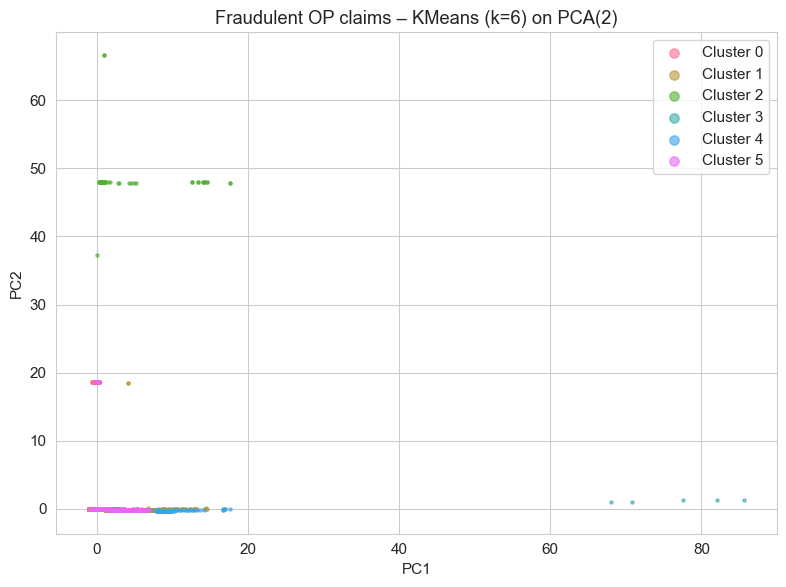

In [34]:
pca_op = PCA(n_components=2, random_state=42)
X_op_pca = pca_op.fit_transform(X_op_scaled)

df_op["pca1_op"] = X_op_pca[:, 0]
df_op["pca2_op"] = X_op_pca[:, 1]

print("OP PCA variance explained (2D):",
      pca_op.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
for cl in sorted(df_op["kmeans_cluster_op"].unique()):
    mask = df_op["kmeans_cluster_op"] == cl
    plt.scatter(
        df_op.loc[mask, "pca1_op"],
        df_op.loc[mask, "pca2_op"],
        s=5,
        alpha=0.6,
        label=f"Cluster {cl}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Fraudulent OP claims – KMeans (k={best_k_op}) on PCA(2)")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [35]:
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS mart.fraud_claims_ip_kmeans"))
    df_ip.to_sql(
        "fraud_claims_ip_kmeans",
        con=conn,
        schema="mart",
        index=False,
        method="multi"
    )

    conn.execute(text("DROP TABLE IF EXISTS mart.fraud_claims_op_kmeans"))
    df_op.to_sql(
        "fraud_claims_op_kmeans",
        con=conn,
        schema="mart",
        index=False,
        method="multi"
    )

print("Wrote KMeans-augmented fraud claim tables to mart.fraud_claims_ip_kmeans and mart.fraud_claims_op_kmeans")

Wrote KMeans-augmented fraud claim tables to mart.fraud_claims_ip_kmeans and mart.fraud_claims_op_kmeans
